In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

# Text preprocessing
import re
from nltk.corpus import stopwords
import nltk

# Wordcloud
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
# Load dataset created from 02_Data_Cleaning
df = pd.read_csv("../data/stage2_cleaned_data.csv")

df.head()

,review_id,user_name,review_text,rating,helpful_votes,app_version,review_date,developer_reply,app_name,review_length,hour,cleaned_review,review_len,word_count
0,016bbd04-7f9c-4c2b-8f82-8d7cab4f424f,Sean Harris,"always happy with their service and goods,just...",5,0,32.4.0.100,2026-03-11 18:25:22,NaN,Amazon Shopping,97,18,"always happy with their service and goods,just...",97,18
1,7a6f39b1-5534-4eed-8100-1cdbedc5ea1e,Finn Fiechtner,pros and cons. 3 star review dead center. cons...,3,0,NaN,2026-03-11 18:15:01,NaN,Amazon Shopping,484,18,pros and cons. 3 star review dead center. cons...,484,82
2,967d3ed1-6855-493d-8816-d7434a22180c,Bassam Yousre,the worst delivery service ever always not on ...,1,0,32.5.0.100,2026-03-11 18:08:16,NaN,Amazon Shopping,141,18,the worst delivery service ever always not on ...,141,26
3,9767efd5-66d8-4dc8-a86f-2c2a26bd0ee4,SO SUPO,happy,4,0,32.5.0.100,2026-03-11 17:57:29,NaN,Amazon Shopping,5,17,happy,5,1
4,26cf286d-c77c-4c64-ba92-dbb119a510fe,Steve Day,Says my phone is not compatible with tap to pa...,1,0,32.5.0.100,2026-03-11 16:45:46,NaN,Amazon Shopping,278,16,says my phone is not compatible with tap to pa...,278,51


In [5]:
# Stopwords list
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review_text'].apply(clean_text)

In [6]:
df['review_length'] = df['review_text'].str.len()

In [7]:
df['word_count'] = df['review_text'].str.split().str.len()

In [8]:
def get_sentiment(text):

    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['clean_review'].apply(get_sentiment)

In [9]:
def sentiment_label(score):

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment_label'] = df['sentiment_score'].apply(sentiment_label)

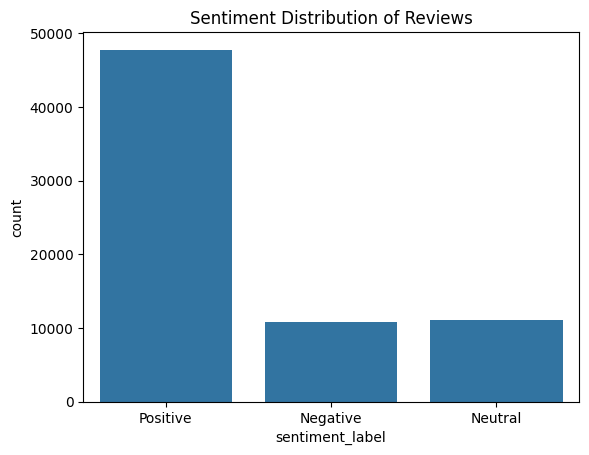

In [10]:
sns.countplot(x='sentiment_label', data=df)
plt.title("Sentiment Distribution of Reviews")
plt.show()

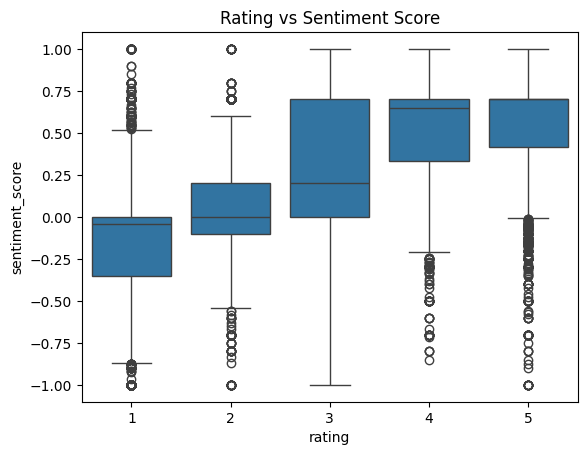

In [11]:
sns.boxplot(x='rating', y='sentiment_score', data=df)
plt.title("Rating vs Sentiment Score")
plt.show()

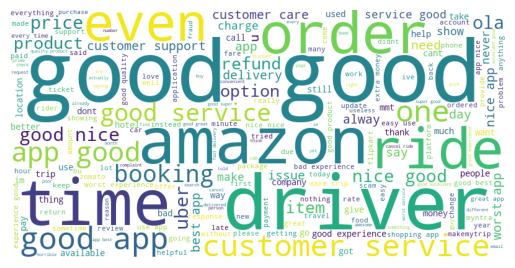

In [12]:
text = " ".join(df['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [15]:
vectorizer = TfidfVectorizer(max_features=2000)

tfidf_matrix = vectorizer.fit_transform(df['clean_review'])

tfidf_matrix.shape

(69737, 2000)

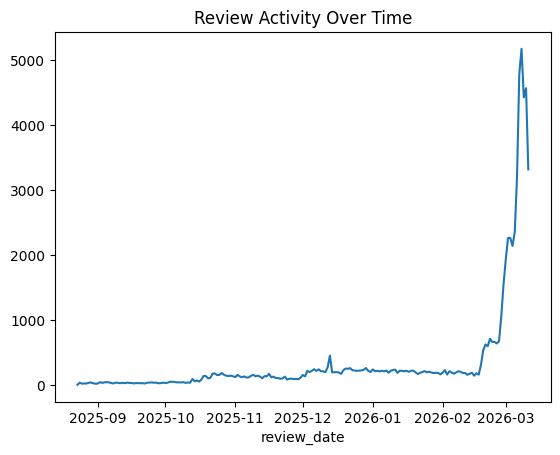

In [14]:
df['review_date'] = pd.to_datetime(df['review_date'])
reviews_per_day = df.groupby(df['review_date'].dt.date).size()

reviews_per_day.plot()
plt.title("Review Activity Over Time")
plt.show()

In [16]:
df.to_csv("../data/stage3_text_features.csv", index=False)